# Week 5 — Visualization with matplotlib

In this notebook, I am practicing data visualization using matplotlib.

I am using the cleaned student dataset from my previous data cleaning task. The goal is to create simple charts that make the data easier to understand.

# Part 1 — Learn: Visualization with matplotlib

## Why visualization matters in data and AI work

Visualization is important because it helps us understand data more clearly. Sometimes, when we only look at a table, it is difficult to notice patterns, differences, or unusual values. But when the same data is shown as a chart, it becomes easier to understand.

In data analysis and AI work, visualization is useful before building a model because it helps us understand the dataset first. It can show trends, outliers, distributions, and relationships between values.

For example, if I only look at student grades in a table, I may not quickly notice which course has the highest average. But if I use a bar chart, the comparison becomes much easier to see.

Visualization is also useful after analysis because it helps explain the results in a simple way.

---

## Basics of matplotlib

`matplotlib` is a Python library used for creating charts and graphs.

The common import is:

```python
import matplotlib.pyplot as plt
```

Some basic matplotlib chart functions are:

```python
plt.plot()
```

This is used to create a line chart. It is useful when we want to show changes or trends.

```python
plt.bar()
```

This is used to create a bar chart. It is useful for comparing categories.

```python
plt.hist()
```

This is used to create a histogram. It is useful for showing the distribution of one numeric column.

```python
plt.scatter()
```

This is used to create a scatter plot. It is useful for showing the relationship between two numeric values.

---

## When to use each chart type

A **bar chart** is useful when comparing categories.
For example, comparing the average grade for each course.

A **histogram** is useful when checking how values are distributed.
For example, seeing how student grades are spread across different ranges.

A **scatter plot** is useful when comparing two numeric values.
For example, checking student number against grade to see how grades are spread across students.

---

## Making charts readable

Charts should be easy to understand. A chart without labels can be confusing, even if the data is correct.

To make charts readable, we should add:

* A clear title
* X-axis label
* Y-axis label
* A legend if there are multiple values or categories

Example:

```python
plt.title("Average Grade per Course")
plt.xlabel("Course")
plt.ylabel("Average Grade")
```

These labels help the viewer understand what the chart is showing.

---

## pandas and plotting

pandas can also connect with plotting using:

```python
df.plot()
```

This is useful because pandas can create quick charts directly from a DataFrame. However, in this task, I am mainly practicing matplotlib because it gives more control over the chart title, labels, and layout.

Overall, visualization helps make cleaned data easier to understand. It is an important step before moving into machine learning because it helps us see what is happening inside the dataset.


# Part 2 — Apply: Creating Visualizations with matplotlib

In this part, I am using the cleaned student dataset from the previous data cleaning task.  
The goal is to create different charts using matplotlib and understand what the data shows visually.

I will create:

- A bar chart to compare average grade per course
- A histogram to see the distribution of grades
- A scatter plot to see how grades are spread across students
- Another bar chart to show the number of students per course

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("cleaned_students.csv")

print("Cleaned Student Dataset:")
df

Cleaned Student Dataset:


,student_id,name,university,course,grade
0,S001,Haameed,AURAK,Python OOP,85.00
1,S002,Ahmed,AURAK,Python OOP,78.00
2,S003,Sara,AURAK,Data Handling,92.00
3,S005,Omar,AURAK,AI Basics,74.00
4,S006,Mariam,Unknown,AI Basics,90.00
5,S007,Yousef,AURAK,Python OOP,84.71
6,S008,Lina,AURAK,Python OOP,82.00


In [17]:
# Final formatting check before creating charts

df["course"] = df["course"].replace({
    "Python Oop": "Python OOP",
    "Ai Basics": "AI Basics"
})

df["grade"] = pd.to_numeric(df["grade"], errors="coerce")

print("Dataset after final formatting check:")
df

Dataset after final formatting check:


,student_id,name,university,course,grade,student_number
0,S001,Haameed,AURAK,Python OOP,85.00,1
1,S002,Ahmed,AURAK,Python OOP,78.00,2
2,S003,Sara,AURAK,Data Handling,92.00,3
3,S005,Omar,AURAK,AI Basics,74.00,4
4,S006,Mariam,Unknown,AI Basics,90.00,5
5,S007,Yousef,AURAK,Python OOP,84.71,6
6,S008,Lina,AURAK,Python OOP,82.00,7


In [11]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   student_id  7 non-null      object 
 1   name        7 non-null      object 
 2   university  7 non-null      object 
 3   course      7 non-null      object 
 4   grade       7 non-null      float64
dtypes: float64(1), object(4)
memory usage: 412.0+ bytes


In [12]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
student_id    0
name          0
university    0
course        0
grade         0
dtype: int64


## Chart 1 — Average Grade per Course

This bar chart shows the average grade for each course.

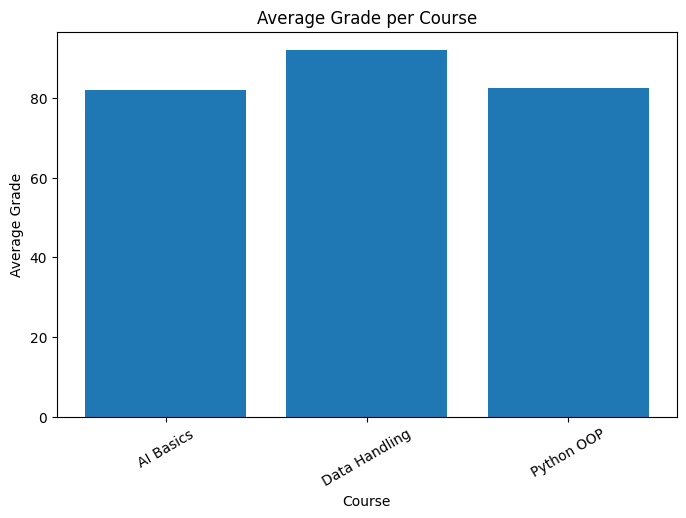

In [18]:
average_grade_per_course = df.groupby("course")["grade"].mean()

plt.figure(figsize=(8, 5))
plt.bar(average_grade_per_course.index, average_grade_per_course.values)

plt.title("Average Grade per Course")
plt.xlabel("Course")
plt.ylabel("Average Grade")

plt.xticks(rotation=30)
plt.show()

This chart shows that Data Handling has the highest average grade, while AI Basics and Python OOP have similar average grades.

## Chart 2 — Grade Distribution

This histogram shows how the student grades are distributed.

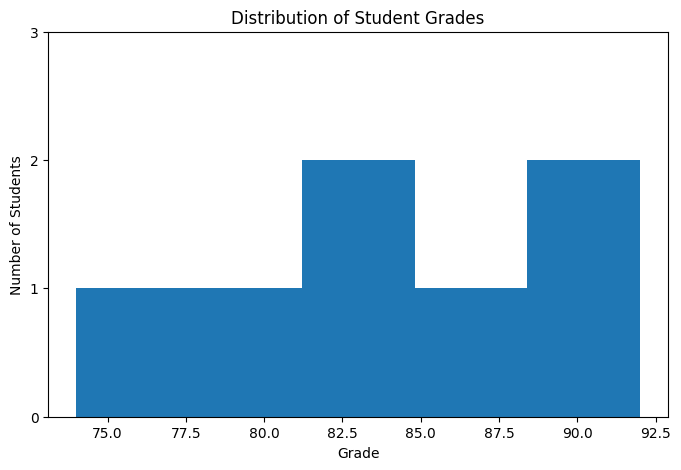

In [20]:
plt.figure(figsize=(8, 5))

counts, bins, patches = plt.hist(df["grade"], bins=5)

plt.title("Distribution of Student Grades")
plt.xlabel("Grade")
plt.ylabel("Number of Students")

plt.yticks(range(0, int(max(counts)) + 2))

plt.show()

This chart shows how the student grades are spread across different grade ranges.

## Chart 3 — Student Number vs Grade

This scatter plot shows how grades are spread across the students in the dataset.

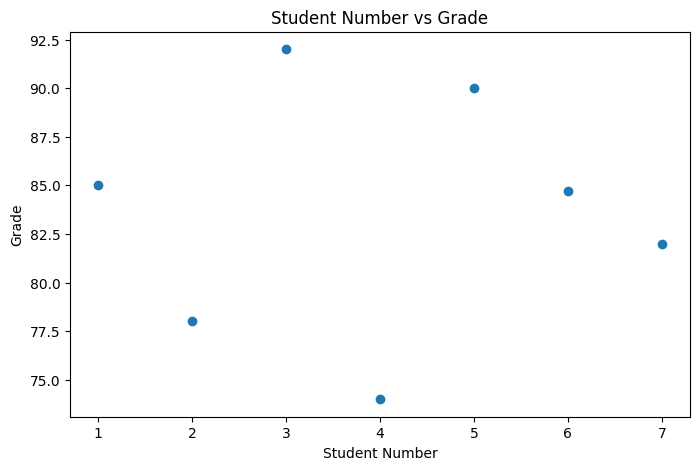

In [21]:
df["student_number"] = range(1, len(df) + 1)

plt.figure(figsize=(8, 5))
plt.scatter(df["student_number"], df["grade"])

plt.title("Student Number vs Grade")
plt.xlabel("Student Number")
plt.ylabel("Grade")

plt.show()

This chart makes it easier to see which students have higher and lower grades.

## Chart 4 — Number of Students per Course

This bar chart shows how many students are listed in each course.

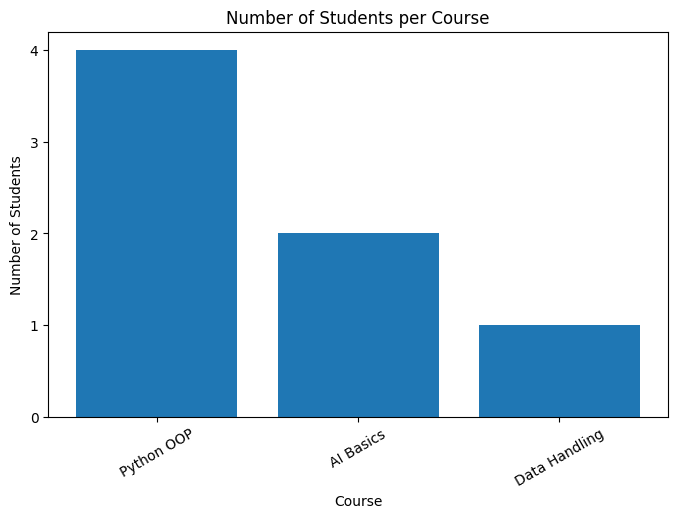

In [22]:
students_per_course = df["course"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(students_per_course.index, students_per_course.values)

plt.title("Number of Students per Course")
plt.xlabel("Course")
plt.ylabel("Number of Students")

plt.xticks(rotation=30)

max_students = students_per_course.max()
plt.yticks(range(0, max_students + 1))

plt.show()

This chart shows which course has the highest number of students in the dataset.

## The Single Most Interesting Thing the Charts Showed Me

The most interesting thing the charts showed me is that visualization makes the cleaned data much easier to understand. From the table alone, it was not very easy to compare courses or notice the grade distribution quickly. But after creating the charts, I could clearly see the average grade per course, how the grades were spread, and how many students were in each course.

This helped me understand why visualization is important in data and AI work. Before building any model, it is useful to first look at the data visually so we can understand patterns, differences, and possible issues.